In [2]:
import os
import random
import shutil
from utils.Dataset import Dataset
import numpy as np
import tensorflow as tf
import matplotlib
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import cv2

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth=True
sess = tf.compat.v1.Session(config=config)

2025-02-05 11:21:07.941240: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-05 11:21:07.993870: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-05 11:21:07.993916: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-05 11:21:07.993951: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-05 11:21:08.004572: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-05 11:21:08.005302: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

--------------------------------------------------
### Dataset statistics ###
Loaded from data/imagesets_1080p/5fold_all/test.txt
Total number of 29002 images.
Total number of 181 polyps. 

Number of classes 3, i.e. [0, 1, 2]
Number of images for each class: 
	 Class 0(HP) = 4375 images, 15.09 % of total. - 46 polyps, 25 % of total
	 Class 1(ADN) = 21810 images, 75.2 % of total. - 120 polyps, 66 % of total
	 Class 2(SSP) = 2817 images, 9.71 % of total. - 16 polyps, 9 % of total


Number of images per polyp: MIN 1 - MED 88.0 - MAX 1537
Respective polyp ids for  : MIN 1312 - MED 1311 - MAX 342
--------------------------------------------------
--------------------------------------------------
### Dataset statistics ###
Loaded from data/imagesets_1080p/5fold_all/test.txt
Total number of 29002 images.
Total number of 181 polyps. 

Number of classes 3, i.e. [0, 1, 2]
Number of images for each class: 
	 Class 0(HP) = 4375 images, 15.09 % of total. - 46 polyps, 25 % of total
	 Class 1(ADN) =

2025-02-05 11:21:34.703624: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


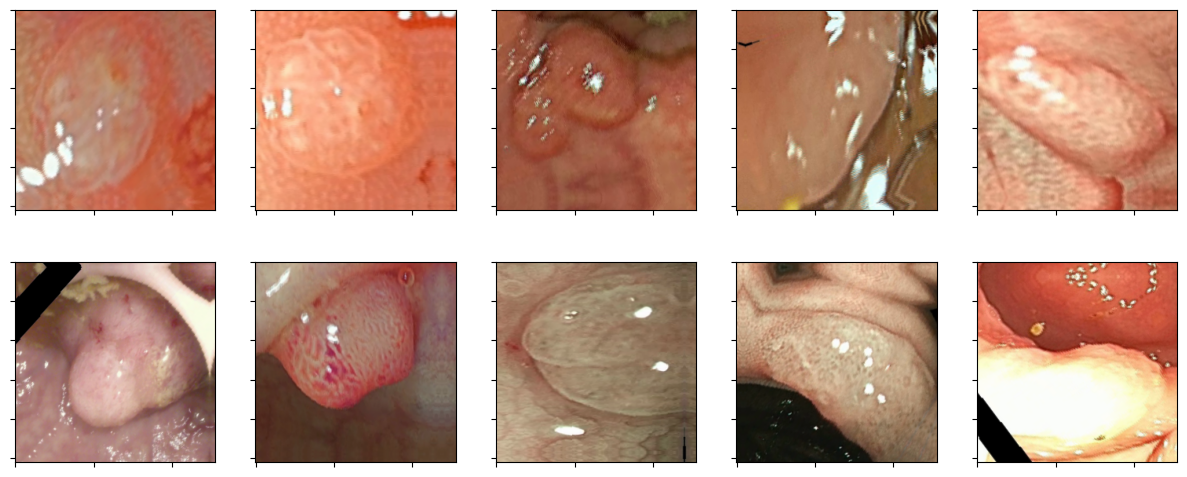

In [4]:
augmentations = {
        "flip_horizontal": True,
        "flip_vertical": True,
        # "cutout": 10,
        "shear": 0.2,
        "rotate": 90.,
        "translate": 20,  # max number of pixels
#         "color": 0.1,
#         "blur": 1.3
        "crop": 0.8,
    }
imageset = "data/imagesets_1080p/5fold_all/test.txt"
ds = Dataset(imageset, batch_size=1, target_size=(256,256),
                       loading_size=(256,256), augmentations=augmentations, nb_inputs=1,
                       balanced=False, do_cropping="preloaded", balance_polypids=False,
                       selected_labels=("0", "1", "2"), nb_classes=3, shuffle=True)

tf.compat.v1.enable_eager_execution()
fig, axs = plt.subplots(2,5, figsize=(15, 6))
i = 0
for image, label in ds.tfdataset.take(10):
    img = np.squeeze(image.numpy())
    
    img = img.astype(int)
    axs[i//5, i%5].imshow(img)
    axs[i//5, i%5].xaxis.set_ticklabels([])
    axs[i//5, i%5].yaxis.set_ticklabels([])
    i += 1  

In [2]:
import pandas as pd  

# Carregar o DataFrame do ficheiro .pkl  
df = pd.read_pickle("results/evaluation_output.pkl")  

# Mostrar as primeiras linhas para ver o conteúdo  
print(df.head())  


   polyp_id            seq             seqs  \
0        14  p004_01_B_WLI  [p004_01_B_WLI]   
1        14  p004_01_B_WLI  [p004_01_B_WLI]   
2        14  p004_01_B_WLI  [p004_01_B_WLI]   
3        14  p004_01_B_WLI  [p004_01_B_WLI]   
4        14  p004_01_B_WLI  [p004_01_B_WLI]   

                                             img_fns  \
0  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/JPEG...   
1  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/JPEG...   
2  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/JPEG...   
3  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/JPEG...   
4  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/JPEG...   

                                             ann_fns      key gt_class  \
0  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/Anno...  [False]        1   
1  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/Anno...  [False]        1   
2  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/Anno...  [False]        1   
3  [/DATASERVER/MIC/SHARED/ENDOSCOPY/EUROPOL/Anno...  [False]        1   
4  [/DATAS

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34904 entries, 0 to 34903
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   polyp_id          34904 non-null  int64 
 1   seq               34904 non-null  object
 2   seqs              34904 non-null  object
 3   img_fns           34904 non-null  object
 4   ann_fns           34904 non-null  object
 5   key               34904 non-null  object
 6   gt_class          34904 non-null  object
 7   exp_smooth        0 non-null      object
 8   cum_exp_smooth    0 non-null      object
 9   fold0_pred        34904 non-null  object
 10  fold0_pred_class  34904 non-null  int64 
 11  fold0_match       34904 non-null  bool  
dtypes: bool(1), int64(2), object(9)
memory usage: 3.0+ MB


In [7]:
df.describe()

,polyp_id,fold0_pred_class
count,34904.000000,34904.000000
mean,788.731206,0.780340
std,398.572268,0.414022
min,14.000000,0.000000
25%,484.000000,1.000000
50%,782.000000,1.000000
75%,1049.000000,1.000000
max,1636.000000,1.000000


In [8]:
accuracy = df["fold0_match"].mean()
print(f"Accuracy: {accuracy:.2%}")


Accuracy: 69.61%


In [9]:
print(df["gt_class"].value_counts())  # Classes reais  
print(df["fold0_pred_class"].value_counts())  # Classes preditas  


gt_class
1    27262
0     7642
Name: count, dtype: int64
fold0_pred_class
1    27237
0     7667
Name: count, dtype: int64


In [10]:
print(df[["fold0_pred", "fold0_pred_class", "gt_class", "fold0_match"]].head(10))


                 fold0_pred  fold0_pred_class gt_class  fold0_match
0   [0.6061312, 0.39386868]                 0        1        False
1   [0.74830014, 0.2516998]                 0        1        False
2   [0.4454984, 0.55450153]                 1        1         True
3  [0.55145085, 0.44854915]                 0        1        False
4        [0.28749, 0.71251]                 1        1         True
5  [0.49719137, 0.50280863]                 1        1         True
6  [0.37699652, 0.62300354]                 1        1         True
7    [0.4918237, 0.5081763]                 1        1         True
8   [0.33437517, 0.6656248]                 1        1         True
9  [0.55161273, 0.44838718]                 0        1        False


(1080, 1920, 3)


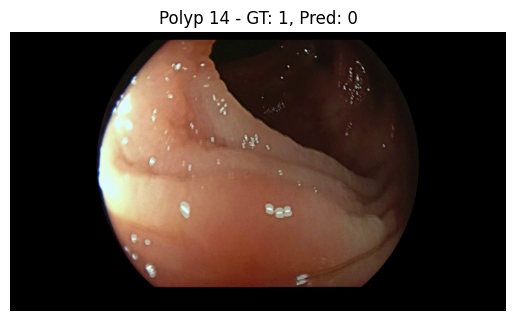

In [7]:
# Filtrar apenas os erros
df_errors = df[df["fold0_match"] == False]

# Selecionar uma imagem de um erro
error_sample = df_errors.iloc[0]  # Escolher o primeiro erro
image_path = error_sample["img_fns"][0]  # Caminho da imagem

# Carregar e exibir a imagem
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Converter de BGR para RGB
print(image.shape)  
plt.imshow(image)
plt.title(f"Polyp {error_sample['polyp_id']} - GT: {error_sample['gt_class']}, Pred: {error_sample['fold0_pred_class']}")
plt.axis("off")
plt.show()

In [ ]:
# Filtrar apenas as previsões corretas
df_correct = df[df["fold0_match"] == True].sample(n=20, random_state=42)  # Seleciona 20 aleatórias

# Criar uma figura para mostrar múltiplas imagens
fig, axes = plt.subplots(4, 5, figsize=(15, 12))  # Grid de 4 linhas x 5 colunas

# Percorrer cada amostra correta e exibir no grid
for ax, (_, sample) in zip(axes.flatten(), df_correct.iterrows()):
    image_path = sample["img_fns"][0]  # Caminho da imagem

    # Carregar a imagem
    image = cv2.imread(image_path)
    if image is None:
        ax.axis("off")
        ax.set_title("Erro ao carregar")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Converter para RGB
    ax.imshow(image)
    ax.set_title(f"Polyp {sample['polyp_id']}\nGT: {sample['gt_class']}, Pred: {sample['fold0_pred_class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2


# Filtrar apenas as previsões corretas
df_correct = df[df["fold0_match"] == True].sample(n=20, random_state=42)  # Seleciona 20 aleatórias

# Criar uma figura para mostrar múltiplas imagens
fig, axes = plt.subplots(4, 5, figsize=(15, 12))  # Grid de 4 linhas x 5 colunas

# Percorrer cada amostra correta e exibir no grid
for ax, (_, sample) in zip(axes.flatten(), df_correct.iterrows()):
    image_path = sample["img_fns"][0]  # Caminho da imagem

    # Carregar a imagem
    image = cv2.imread(image_path)
    if image is None:
        ax.axis("off")
        ax.set_title("Erro ao carregar")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Converter para RGB
    ax.imshow(image)
    ax.set_title(f"Polyp {sample['polyp_id']}\nGT: {sample['gt_class']}, Pred: {sample['fold0_pred_class']}")
    ax.axis("off")

plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

In [23]:
from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np
import cv2
from keras.models import load_model
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model('/DATASERVER/MIC/GENERAL/STUDENTS/amartic/mscthesis/polypclassificationmi/data/snapshots/all/hypVSadn_enhancedContrast_HDall2024_resnet_0_regularized0.0_256x256_1in_nf64_bnTrue_fcdo0.0_balancedTrue_loss_ce_lossls0.4_sgd_1fold0_final.h5', compile=False)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 tf.math.truediv (TFOpLambd  (None, 256, 256, 3)          0         ['input_1[0][0]']             
 a)                                                                                               
                                                                                                  
 tf.math.subtract (TFOpLamb  (None, 256, 256, 3)          0         ['tf.math.truediv[0][0]']     
 da)                                                                                              
                                                                                              

In [22]:
import os
import numpy as np
import cv2
import shap
import matplotlib.pyplot as plt

# Path to one of your npz files
npz_file = "/DATASERVER/MIC/GENERAL/STUDENTS/amartic/mscthesis/polypclassificationmi/shap_results/shap_00025.npz"

# Load the npz file
data = np.load(npz_file)
shap_values = data["shap_values"]  # Expected shape: (1, 256, 256, 3, 2)
base_values = data["base_values"]  # Expected shape: (1, 2)

print("SHAP values shape:", shap_values.shape)
print("Base values shape:", base_values.shape)

# Since the model has 2 classes, shap_values has an extra dimension.
# For visualization, you can choose one class, e.g., class 0.
# Extract the SHAP values for class 0:
shap_values_class0 = shap_values[0, :, :, :, 0]  # Shape becomes (256, 256, 3)

# Add a batch dimension so that shap.image_plot can work with it:
shap_values_class0 = np.expand_dims(shap_values_class0, axis=0)  # Now shape is (1, 256, 256, 3)

# Now, load the sample image that was explained.
# (Make sure this is the same image that was used to compute the SHAP values)
# For example, adjust the path below to the sample image you used:
sample_image_path = "/DATASERVER/MIC/GENERAL/STUDENTS/amartic/mscthesis/polypclassificationmi/data/imagesets_characterisation/some_sample_image.png"
sample_image = cv2.imread(sample_image_path, cv2.IMREAD_COLOR)
if sample_image is None:
    raise ValueError("Could not load the sample image from the provided path.")
sample_image = cv2.resize(sample_image, (256, 256))
sample_image = sample_image.astype("float32") / 255.0
sample_image = np.expand_dims(sample_image, axis=0)  # Now shape is (1, 256, 256, 3)

# Plot the SHAP values overlaying the sample image
shap.image_plot([shap_values_class0[0]], sample_image)
plt.show()


SHAP values shape: (1, 256, 256, 3, 2)
Base values shape: (1, 2)


ValueError: Could not load the sample image from the provided path.